# Online Retail — Sales & Customer Analysis

**Dataset:** UCI "Online Retail" dataset — ~541,909 real e-commerce transactions
from a UK-based online retailer, 01-Dec-2010 to 09-Dec-2011.

**Source of data used here:** the cleaned `transactions` / `customers` / `products`
tables produced by the ETL pipeline in `src/etl/` (`pipeline.py` runs
extract → transform → load and writes `data/processed/retail.db`).

This notebook is the "data analyst" half of the project: it answers business
questions about sales trends, top products/countries, and customer value via
RFM (Recency, Frequency, Monetary) segmentation, and saves each chart to
`outputs/figures/` so they render on GitHub without needing to run anything.


In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DB_PATH = PROJECT_ROOT / "data" / "processed" / "retail.db"
FIG_DIR = PROJECT_ROOT / "outputs" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

conn = sqlite3.connect(DB_PATH)
transactions = pd.read_sql("SELECT * FROM transactions", conn, parse_dates=["invoice_date"])
customers = pd.read_sql("SELECT * FROM customers", conn)
products = pd.read_sql("SELECT * FROM products", conn)
conn.close()

print(f"transactions: {transactions.shape}")
print(f"customers:    {customers.shape}")
print(f"products:     {products.shape}")
transactions.head()


transactions: (524876, 9)
customers:    (4338, 2)
products:     (3922, 2)


,invoice_no,stock_code,customer_id,quantity,unit_price,total_price,invoice_date,country,is_guest
0,536365,85123A,17850.0,6,2.55,15.30,2010-12-01 08:26:00,United Kingdom,0
1,536365,71053,17850.0,6,3.39,20.34,2010-12-01 08:26:00,United Kingdom,0
2,536365,84406B,17850.0,8,2.75,22.00,2010-12-01 08:26:00,United Kingdom,0
3,536365,84029G,17850.0,6,3.39,20.34,2010-12-01 08:26:00,United Kingdom,0
4,536365,84029E,17850.0,6,3.39,20.34,2010-12-01 08:26:00,United Kingdom,0


## 1. Sales Trends Over Time

Revenue by month and by week across the full ~12-month window covered by the
dataset. December 2011 is a partial month (data ends 2011-12-09), which shows
up as a dip at the very end of the series — noted rather than hidden.


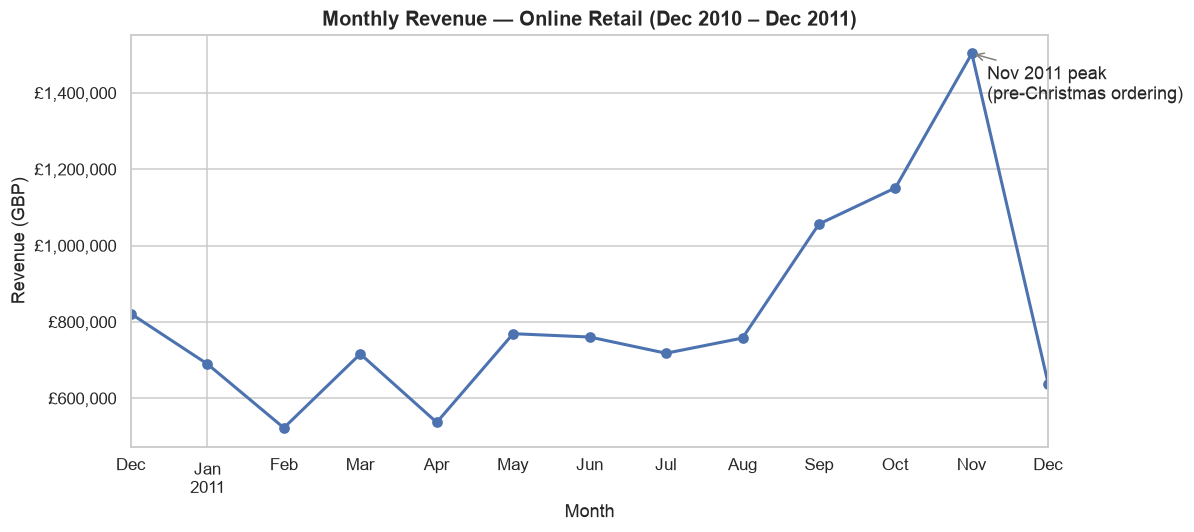

Best month: 2011-11 — £1,503,329.78
Total revenue across window: £10,641,558.95


In [2]:
monthly_revenue = (
    transactions.set_index("invoice_date")["total_price"]
    .resample("MS")
    .sum()
)

fig, ax = plt.subplots(figsize=(11, 5))
monthly_revenue.plot(ax=ax, marker="o", linewidth=2, color="#4C72B0")
ax.set_title("Monthly Revenue — Online Retail (Dec 2010 – Dec 2011)", fontsize=13, fontweight="bold")
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (GBP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
ax.annotate(
    "Nov 2011 peak\n(pre-Christmas ordering)",
    xy=(monthly_revenue.idxmax(), monthly_revenue.max()),
    xytext=(10, -30),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="gray"),
)
plt.tight_layout()
plt.savefig(FIG_DIR / "01_monthly_revenue.png", bbox_inches="tight")
plt.show()

print(f"Best month: {monthly_revenue.idxmax().strftime('%Y-%m')} — £{monthly_revenue.max():,.2f}")
print(f"Total revenue across window: £{monthly_revenue.sum():,.2f}")


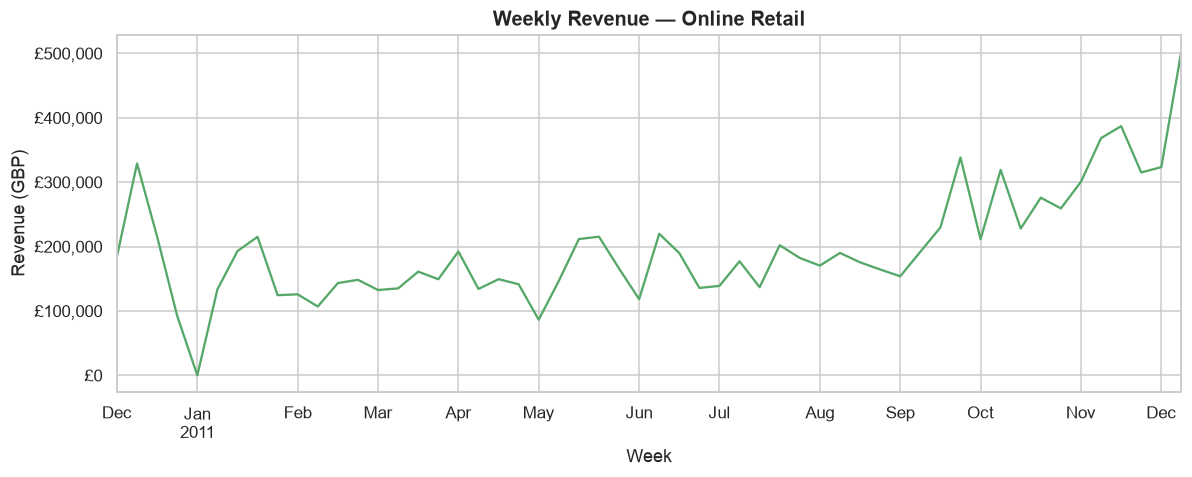

In [3]:
weekly_revenue = (
    transactions.set_index("invoice_date")["total_price"]
    .resample("W")
    .sum()
)

fig, ax = plt.subplots(figsize=(11, 4.5))
weekly_revenue.plot(ax=ax, color="#55A868", linewidth=1.5)
ax.set_title("Weekly Revenue — Online Retail", fontsize=13, fontweight="bold")
ax.set_xlabel("Week")
ax.set_ylabel("Revenue (GBP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.tight_layout()
plt.savefig(FIG_DIR / "02_weekly_revenue.png", bbox_inches="tight")
plt.show()


## 2. Top Products and Top Countries by Revenue

`DOTCOM POSTAGE` and generic `POSTAGE` / `Manual` line items are shipping and
manual-adjustment charges rather than physical products, and are left in
place (not stripped) since they are still real, legitimate revenue lines in
the source data — but they're worth calling out explicitly when reading the
"top products" list.


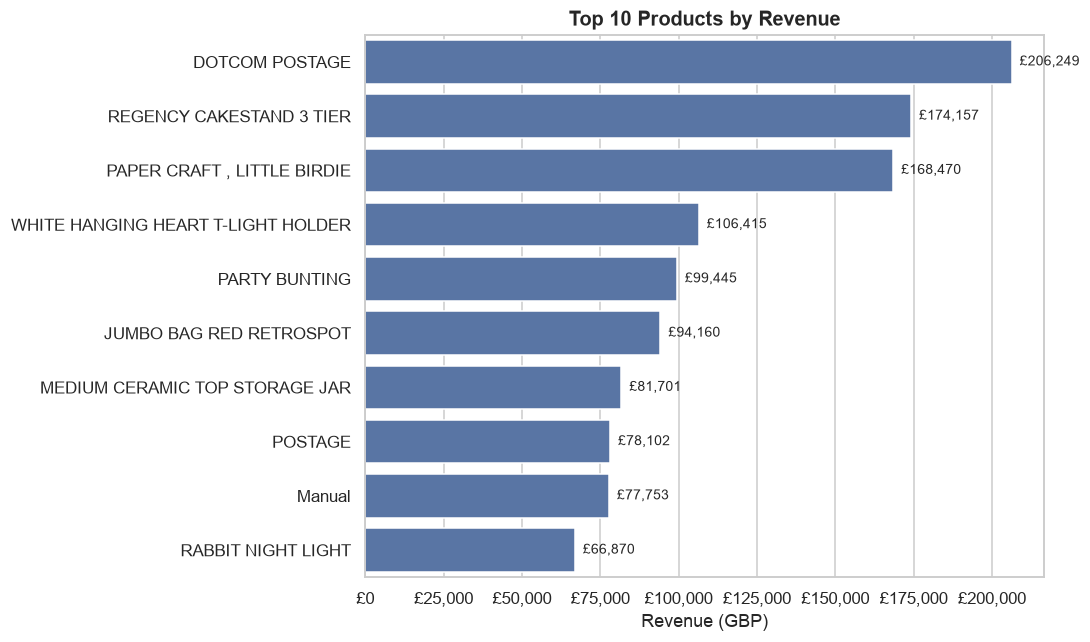

In [4]:
tx_products = transactions.merge(products, on="stock_code", how="left")
top_products = (
    tx_products.groupby("description")["total_price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_products.values, y=top_products.index, ax=ax, color="#4C72B0")
ax.set_title("Top 10 Products by Revenue", fontsize=13, fontweight="bold")
ax.set_xlabel("Revenue (GBP)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
for i, v in enumerate(top_products.values):
    ax.text(v, i, f"  £{v:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "03_top_products.png", bbox_inches="tight")
plt.show()


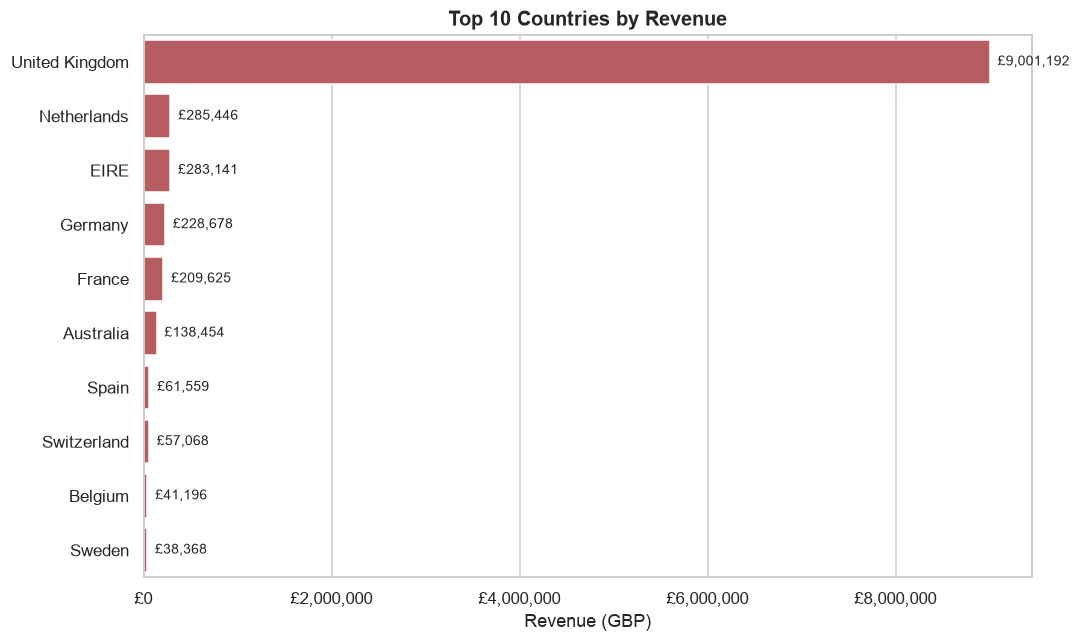

United Kingdom accounts for 84.6% of total revenue
country
United Kingdom    9001192.24
Netherlands        285446.34
EIRE               283140.52
Germany            228678.40
France             209625.37
Australia          138453.81
Spain               61558.56
Switzerland         57067.60
Belgium             41196.34
Sweden              38367.83
Name: total_price, dtype: float64


In [5]:
top_countries = (
    transactions.groupby("country")["total_price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
uk_share = 100 * top_countries.get("United Kingdom", 0) / transactions["total_price"].sum()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top_countries.values, y=top_countries.index, ax=ax, color="#C44E52")
ax.set_title("Top 10 Countries by Revenue", fontsize=13, fontweight="bold")
ax.set_xlabel("Revenue (GBP)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
for i, v in enumerate(top_countries.values):
    ax.text(v, i, f"  £{v:,.0f}", va="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "04_top_countries.png", bbox_inches="tight")
plt.show()

print(f"United Kingdom accounts for {uk_share:.1f}% of total revenue")
print(top_countries)


## 3. Customer Segmentation — RFM Analysis

RFM scores each customer on:
- **Recency** — days since their last purchase (lower = better)
- **Frequency** — number of distinct invoices (higher = better)
- **Monetary** — total revenue from that customer (higher = better)

Only transactions with a known `customer_id` are used here (guest/no-account
checkouts, ~25% of rows, can't be attributed to a customer and are excluded
from this specific analysis — they're still included in the revenue/time
analyses above).

Each customer is quartile-scored 1-4 on each dimension and summed into an
RFM score, then bucketed into a segment.


In [6]:
rfm_tx = transactions[transactions["customer_id"].notna()]
snapshot_date = rfm_tx["invoice_date"].max() + pd.Timedelta(days=1)

rfm = rfm_tx.groupby("customer_id").agg(
    Recency=("invoice_date", lambda s: (snapshot_date - s.max()).days),
    Frequency=("invoice_no", "nunique"),
    Monetary=("total_price", "sum"),
).reset_index()

rfm["R"] = pd.qcut(rfm["Recency"], 4, labels=[4, 3, 2, 1]).astype(int)
rfm["F"] = pd.qcut(rfm["Frequency"].rank(method="first"), 4, labels=[1, 2, 3, 4]).astype(int)
rfm["M"] = pd.qcut(rfm["Monetary"], 4, labels=[1, 2, 3, 4]).astype(int)
rfm["RFM_Score"] = rfm["R"] + rfm["F"] + rfm["M"]

def segment(score: int) -> str:
    if score >= 10:
        return "Champions"
    elif score >= 8:
        return "Loyal Customers"
    elif score >= 6:
        return "Potential Loyalists"
    elif score >= 4:
        return "At Risk"
    else:
        return "Lost"

rfm["Segment"] = rfm["RFM_Score"].apply(segment)
rfm.describe()


,customer_id,Recency,Frequency,Monetary,R,F,M,RFM_Score
count,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000,4338.000000
mean,15300.408022,92.536422,4.272015,2048.560867,2.513831,2.500000,2.500000,7.513831
std,1721.808492,100.014169,7.697998,8984.682547,1.126296,1.118369,1.118369,2.827109
min,12346.000000,1.000000,1.000000,3.750000,1.000000,1.000000,1.000000,3.000000
25%,13813.250000,18.000000,1.000000,306.482500,2.000000,1.250000,1.250000,5.000000
50%,15299.500000,51.000000,2.000000,668.570000,3.000000,2.500000,2.500000,7.000000
75%,16778.750000,142.000000,5.000000,1660.597500,4.000000,3.750000,3.750000,10.000000
max,18287.000000,374.000000,209.000000,280206.020000,4.000000,4.000000,4.000000,12.000000


/var/folders/h0/965krwk91nj77j9ncpk4r_8m0000gn/T/ipykernel_74086/2638983673.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=ax, palette=palette)


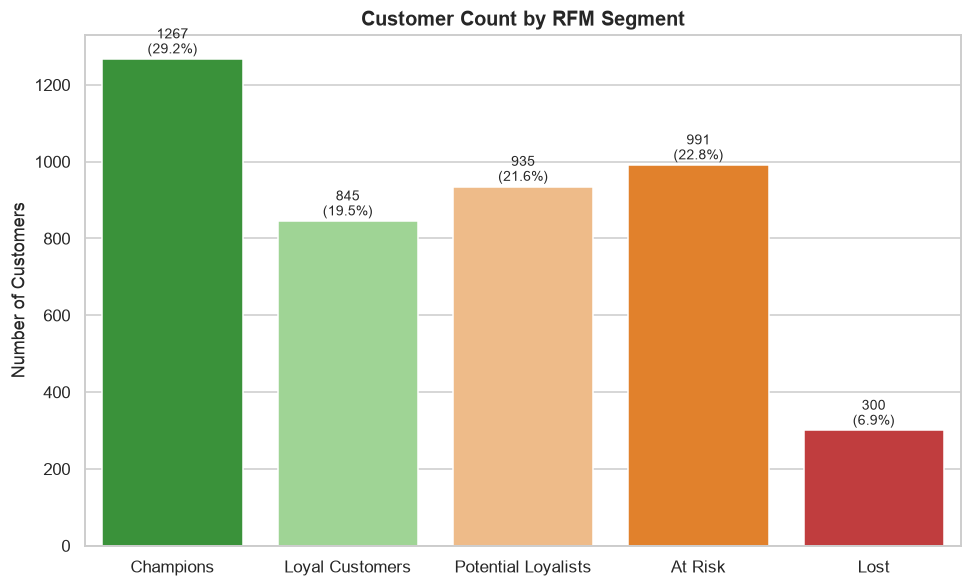

Segment
Champions              1267
Loyal Customers         845
Potential Loyalists     935
At Risk                 991
Lost                    300
Name: count, dtype: int64

Champions are 29.2% of customers but generate 76.8% of total customer revenue.


In [7]:
segment_order = ["Champions", "Loyal Customers", "Potential Loyalists", "At Risk", "Lost"]
segment_counts = rfm["Segment"].value_counts().reindex(segment_order)
segment_pct = 100 * segment_counts / segment_counts.sum()

fig, ax = plt.subplots(figsize=(9, 5.5))
palette = ["#2ca02c", "#98df8a", "#ffbb78", "#ff7f0e", "#d62728"]
sns.barplot(x=segment_counts.index, y=segment_counts.values, ax=ax, palette=palette)
ax.set_title("Customer Count by RFM Segment", fontsize=13, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Number of Customers")
for i, (count, pct) in enumerate(zip(segment_counts.values, segment_pct.values)):
    ax.text(i, count + 15, f"{count}\n({pct:.1f}%)", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig(FIG_DIR / "05_rfm_segments.png", bbox_inches="tight")
plt.show()

print(segment_counts)
champions_revenue_share = 100 * rfm.loc[rfm.Segment == "Champions", "Monetary"].sum() / rfm["Monetary"].sum()
print(f"\nChampions are {segment_pct['Champions']:.1f}% of customers but generate "
      f"{champions_revenue_share:.1f}% of total customer revenue.")


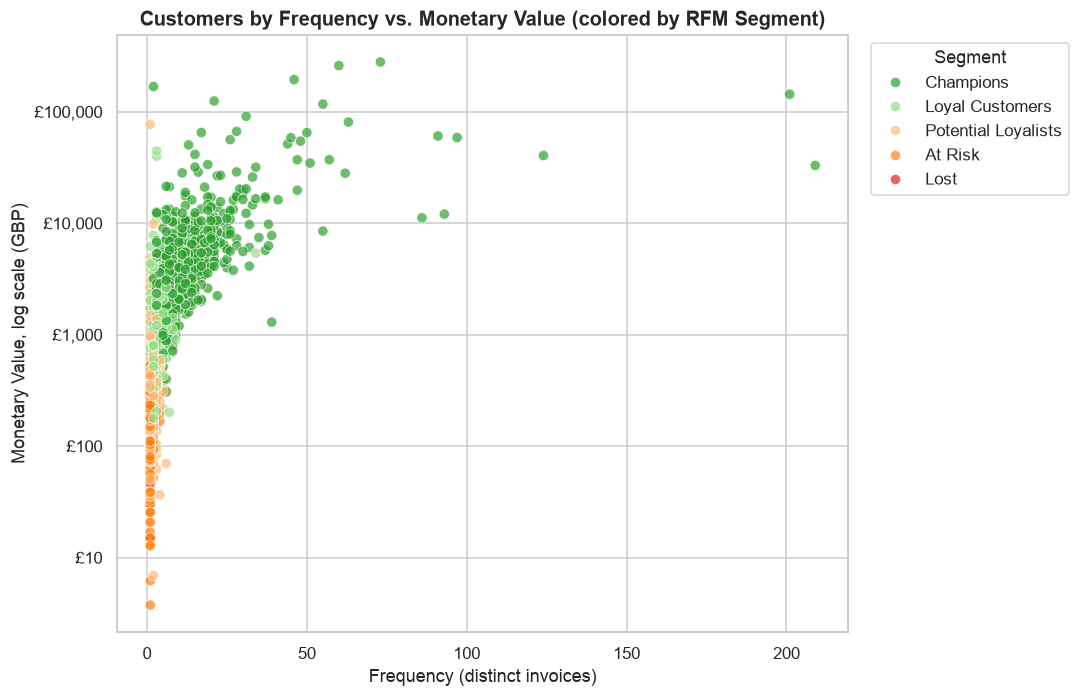

In [8]:
fig, ax = plt.subplots(figsize=(10, 6.5))
scatter = sns.scatterplot(
    data=rfm,
    x="Frequency",
    y="Monetary",
    hue="Segment",
    hue_order=segment_order,
    palette=palette,
    alpha=0.7,
    s=45,
    ax=ax,
)
ax.set_yscale("log")
ax.set_title("Customers by Frequency vs. Monetary Value (colored by RFM Segment)", fontsize=13, fontweight="bold")
ax.set_xlabel("Frequency (distinct invoices)")
ax.set_ylabel("Monetary Value, log scale (GBP)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}"))
plt.legend(title="Segment", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(FIG_DIR / "06_rfm_scatter.png", bbox_inches="tight")
plt.show()


## Key Findings

*(All figures computed directly from the cleaned dataset — see `data/processed/retail.db` /
`outputs/figures/` for the underlying data and charts.)*

1. **Revenue & scale.** The cleaned dataset covers **524,876 order lines**
   across **19,960 invoices** from **4,338 identified customers**, totalling
   **£10,641,558.95** in revenue between Dec 2010 and Dec 2011 (541,909 raw
   rows in, 17,033 dropped — 3.1% — as cancellations, invalid quantities/prices,
   or missing product descriptions; see the ETL section of the README for the
   full breakdown).
2. **Seasonality.** Revenue trends upward through the year and peaks in
   **November 2011 at £1,503,329.78** — nearly double the February 2011 low
   of £522,545.56 — consistent with pre-Christmas ordering by this
   wholesale/gift retailer. December 2011 is a partial month in the source
   data (cut off on the 9th) so its lower total is an artifact of the data
   window, not a real decline.
3. **Geographic concentration.** The retailer is overwhelmingly
   **UK-centric: 84.6% of revenue (£9,001,192)** comes from the United
   Kingdom. The next largest markets — Netherlands, EIRE (Ireland), Germany,
   and France — each contribute under 3% individually, indicating major
   headroom (and risk concentration) internationally.
4. **Top products.** Beyond shipping/adjustment line items (`DOTCOM POSTAGE`,
   `POSTAGE`, `Manual`), the top physical product by revenue is the
   **REGENCY CAKESTAND 3 TIER at £174,156.54**, followed by
   **PAPER CRAFT, LITTLE BIRDIE (£168,469.60)** and the
   **WHITE HANGING HEART T-LIGHT HOLDER (£106,415.23)** — the retailer's
   best-known, most iconic product.
5. **Customer value is extremely concentrated.** RFM segmentation of the
   4,338 identified customers found **1,267 "Champions" (29.2% of
   customers)** who together generate **76.8% of total customer revenue** —
   a textbook Pareto pattern. The largest single customer (ID 14646)
   contributed **£280,206.02** across 73 orders in the year. Conversely,
   **300 customers (6.9%) are "Lost"** — low recency, frequency, and spend —
   representing a concrete win-back marketing target.
6. **Order economics.** The average order value is **£533.14** (median
   £303.30) — the gap between mean and median indicates a right-skewed
   distribution driven by a smaller number of large wholesale-style orders,
   consistent with this being a B2B-leaning online retailer rather than a
   typical B2C storefront.

**Business takeaways:** invest retention spend on the ~1,267 Champions
segment (it drives ~77% of revenue), build a win-back campaign for the ~300
Lost customers, and treat international markets outside the UK as a growth
opportunity given how concentrated revenue currently is domestically.
